# Extra-Mile 1 — Exploring the Installation Dataset
**Task:** Load and explore `data/installed.json` to understand the structure of the elevator installation dataset and how it relates to `license.csv`.

---
## 1. Dataset Structure

Load `installed.json` and document its shape, column names, data types, and a sample of rows.

In [1]:
import pandas as pd

df = pd.read_json('../data/installed.json')
print('Shape:', df.shape)
df.head()

Shape: (46936, 9)


,Elevating devices number,Owner Name,Owner Address,Owner Account Number,Device Class,Device Type,DeviceStatus,Location of Device,under review
0,8,LEGISLATIVE ASSEMBLY OF ONTARIO ATTN: JOHN ED...,99 WELLESLEY ST W WHITNEY BLOCK ROOM 2540 TOR...,redacted,Elevators,Passenger Elevator,Active,111 WELLESLEY ST W TORONTO M7A 1A2 ON CA,N
1,9,LEGISLATIVE ASSEMBLY OF ONTARIO ATTN: JOHN ED...,99 WELLESLEY ST W WHITNEY BLOCK ROOM 2540 TOR...,redacted,Elevators,Passenger Elevator,Active,111 WELLESLEY ST W TORONTO M7A 1A2 ON CA,N
2,10,LEGISLATIVE ASSEMBLY OF ONTARIO ATTN: JOHN ED...,99 WELLESLEY ST W WHITNEY BLOCK ROOM 2540 TOR...,redacted,Elevators,Passenger Elevator,Active,111 WELLESLEY ST W TORONTO M7A 1A2 ON CA,N
3,11,LEGISLATIVE ASSEMBLY OF ONTARIO ATTN: JOHN ED...,99 WELLESLEY ST W WHITNEY BLOCK ROOM 2540 TOR...,redacted,Elevators,Passenger Elevator,Active,111 WELLESLEY ST W TORONTO M7A 1A2 ON CA,N
4,13,LEGISLATIVE ASSEMBLY OF ONTARIO ATTN: JOHN ED...,99 WELLESLEY ST W WHITNEY BLOCK ROOM 2540 TOR...,redacted,Elevators,Passenger Elevator,Active,111 WELLESLEY ST W TORONTO M7A 1A2 ON CA,N


In [2]:
print('Columns and data types:')
print(df.dtypes)

Columns and data types:
Elevating devices number    int64
Owner Name                    str
Owner Address                 str
Owner Account Number          str
Device Class                  str
Device Type                   str
DeviceStatus                  str
Location of Device            str
under review                  str
dtype: object


---
## 2. Device Type Distribution

Count how frequently each device type appears and visualize the results as a horizontal bar chart.

In [3]:
device_type_counts = df['Device Type'].value_counts()
print(device_type_counts)

Device Type
Passenger Elevator      42405
Freight Elevator         2912
LULA Elevator            1254
Observation Elevator      325
Freight Elevator-P         17
Freight Elevator-E         11
Sidewalk Elevator           5
Temporary Elevator          4
Material Lift - ATD         1
Special Installation        1
Power Type Manlift          1
Name: count, dtype: int64


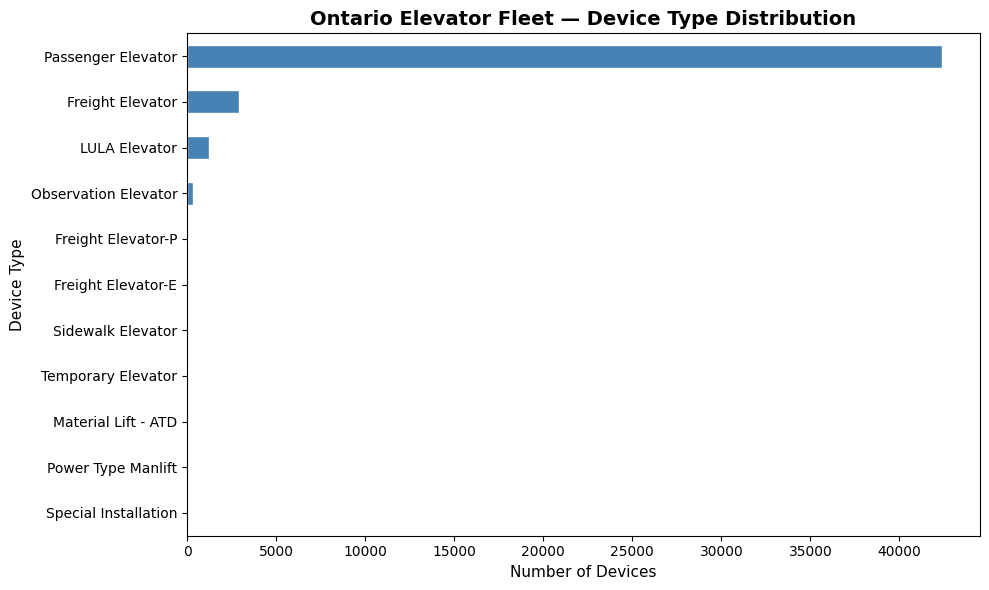

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

device_type_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')

ax.set_title('Ontario Elevator Fleet — Device Type Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Devices', fontsize=11)
ax.set_ylabel('Device Type', fontsize=11)

plt.tight_layout()
plt.show()

---
## 3. Device Status Distribution

Examine the distribution of device statuses across the fleet.

In [5]:
status_counts = df['DeviceStatus'].value_counts()
print(status_counts)

DeviceStatus
Active                  44731
Customer Shutdown         947
Inactive                  661
TSSA Shutdown             595
Undergoing Major Alt        2
Name: count, dtype: int64


---
## 4. Comparison with license.csv

`installed.json` contains information that `license.csv` does not. Where `license.csv` focuses on the legal and administrative side of elevator operation — license numbers, expiry dates, license holders, and billing details — `installed.json` describes the physical device itself: its type (Passenger Elevator, Freight Elevator, LULA Elevator, etc.), its operational status (Active, Customer Shutdown, TSSA Shutdown, etc.), its owner, and its location. The two datasets cover different aspects of the same elevator fleet and are designed to be used together.

The column that connects the two datasets is the elevator device number. In `license.csv` this is called `ElevatingDevicesNumber`; in `installed.json` it is called `Elevating devices number`. Both contain the same integer identifiers, making this the natural join key for any cross-dataset analysis in Module 2.

`installed.json` uniquely provides `Device Type` and `DeviceStatus` — neither of which appears in `license.csv`. This means any analysis that needs to filter or group by elevator type (e.g., how many freight elevators have expired licenses) or by operational status (e.g., which TSSA Shutdown elevators are also overdue for inspection) must join across both files using the device number as the key.